In [1]:
# 🧠 人民公社聚类分析（本地运行版）
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# 1. 加载数据文件（修改为你的实际路径）
file_path = r"E:\【论文】\heritage science\0609Chinese_knowledge_graph\commune_vector_final.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')

In [3]:
# 2. 删除无法聚类的非数值列（如 name、location 等）
non_numeric_cols = ['name', 'location'] if 'location' in df.columns else ['name']
df_features = df.drop(columns=[col for col in non_numeric_cols if col in df.columns])

In [4]:
# 3. 保证所有特征为数值型（可选，你文件已处理过通常不需要）
df_features = df_features.select_dtypes(include='number')

In [9]:
import numpy as np

# 检查是否存在 NaN 或 inf
print("是否有缺失值：", df_features.isnull().values.any())
print("是否有无穷值：", np.isinf(df_features.values).any())

# 清洗 NaN 和 inf
df_features_clean = df_features.replace([np.inf, -np.inf], np.nan).dropna()

# 为了保持一致，还需同步删除原始 df 中对应行
df_clean = df.loc[df_features_clean.index].copy()

是否有缺失值： True
是否有无穷值： False


In [11]:
# 5. KMeans 聚类（设为6类，可根据需要调整）
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(df_features_clean)

In [12]:
# 6. PCA 降维，用于可视化
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_features_clean)
df_clean['pca1'], df_clean['pca2'] = pca_result[:, 0], pca_result[:, 1]

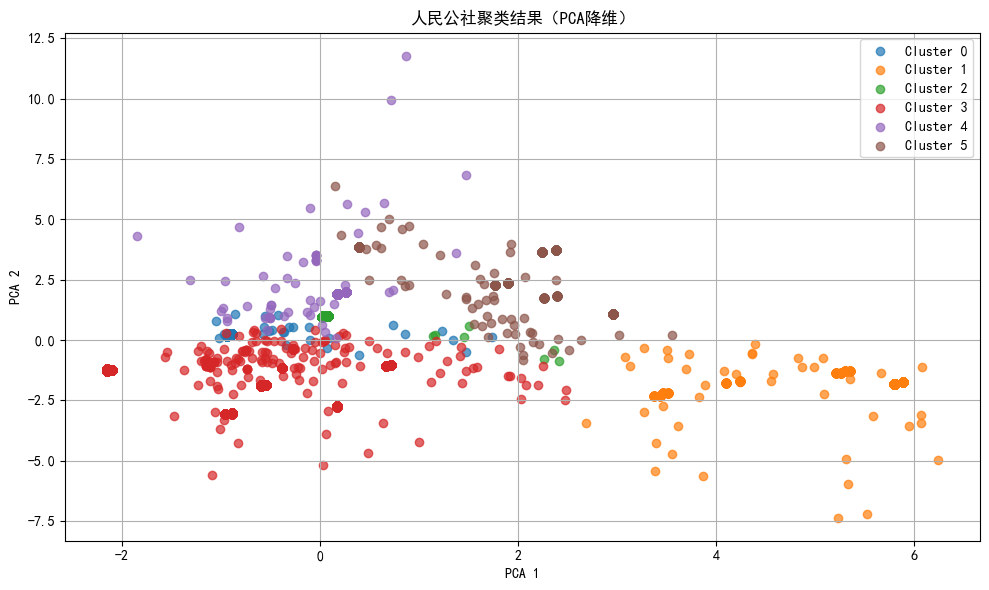

✅ 聚类完成，结果已保存为：E:\【论文】\heritage science\0609Chinese_knowledge_graph\commune_vector_final_clustered.csv


In [17]:
# 7. 可视化聚类结果
plt.figure(figsize=(10, 6))
for i in range(n_clusters):
    cluster_points = df_clean[df_clean['cluster'] == i]
    plt.scatter(cluster_points['pca1'], cluster_points['pca2'], label=f'Cluster {i}', alpha=0.7)
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False
plt.title("人民公社聚类结果（PCA降维）")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. 保存带有聚类标签的数据
output_path = file_path.replace(".csv", "_clustered.csv")
df.to_csv(output_path, index=False, encoding='utf-8-sig')
df_clean.to_csv(r"E:\【论文】\heritage science\0609Chinese_knowledge_graph\commune_vector_final_clustered.csv", index=False, encoding="utf-8-sig")
print(f"✅ 聚类完成，结果已保存为：{output_path}")

In [15]:
for i in range(n_clusters):
    print(f"\n📍 Cluster {i}:")
    print(df_clean[df_clean['cluster'] == i]['name'].tolist())


📍 Cluster 0:
['陵口', '粮山', '酒甸', '界首', '江东', '环城', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '红旗', '

In [16]:
cluster_summary = df_clean.groupby('cluster').mean(numeric_only=True)
pd.set_option('display.max_columns', None)
display(cluster_summary)

,lat,lon,agri_中稻,agri_二季,agri_人参,agri_低产,agri_作,agri_作物,agri_养兔,agri_养牛,agri_养猪,agri_养猪场,agri_养畜,agri_养禽,agri_养蚕,agri_养蜂,agri_养鱼,agri_农具,agri_农副业,agri_农机具,agri_农耕,agri_农船,agri_制粉,agri_副业,agri_副业生产,agri_化学肥料,agri_化肥,agri_南瓜,agri_名茶,agri_土,agri_土化,agri_土化肥,agri_土地,agri_土壤,agri_圩塘,agri_增产,agri_士农,agri_大蒜,agri_大豆,agri_大麦,agri_大麻,agri_太湖银鱼,agri_家畜,agri_小米,agri_小麦,agri_山区,agri_干菜,agri_户麦亩,agri_手工业,agri_手艺,agri_拖拉机,agri_捕鱼,agri_排灌,agri_收获量,agri_施肥,agri_施肥量,agri_早熟,agri_春蚕,agri_木材,agri_木槿,agri_木炭,agri_木碳,agri_杀虫剂,agri_杂粮,agri_杂谷,agri_杉,agri_杨树,agri_杨槐,agri_林业,agri_果树,agri_果物,agri_柳,agri_柳梨桃,agri_桑,agri_桑园,agri_梅鲚鱼,agri_棉花,agri_植树,agri_榆,agri_榉,agri_槐,agri_水果,agri_水生植物,agri_水稻,agri_水面,agri_沂河,agri_河泥,agri_油料作物,agri_油桐,agri_油菜籽,agri_洋葱,agri_淡水,agri_淡水鱼,agri_深耕,agri_渔业,agri_湿地,agri_灌溉,agri_烟草,agri_烧,agri_牛,agri_牛米,agri_牛草,agri_牧畜,agri_狩猎,agri_狩鱼,agri_猪,agri_猪羊,agri_玉米,agri_瓜,agri_生产,agri_生产队,agri_田,agri_田亩,agri_畜牧,agri_番薯,agri_白菜,agri_百合,agri_石楠,agri_石灰,agri_碧螺春,agri_秋,agri_秋作,agri_种子,agri_种植,agri_竹,agri_竹器,agri_竹木,agri_竹材,agri_竹林,agri_竹柳,agri_竹瓦,agri_米,agri_米绵,agri_米藤芋,agri_米麦,agri_粟,agri_粪便储藏,agri_粮食,agri_粮食作物,agri_精油,agri_红薯,agri_经济作物,agri_绳索,agri_绵,agri_绵年,agri_绵油,agri_绵麦,agri_绿地,agri_绿肥,agri_绿豆,agri_编织,agri_编织物,agri_羊,agri_羊麦,agri_耕地,agri_耕牛,agri_肥,agri_肥料,agri_胡萝卜,agri_芋头,agri_芝麻,agri_芦苇,agri_花生,agri_茄子,agri_茶,agri_荞麦,agri_药,agri_药材,agri_药水,agri_莲连根,agri_菊,agri_菜种,agri_菱角,agri_萝卜,agri_落花生,agri_蔬菜,agri_薄荷,agri_虫,agri_虫害,agri_蚕豆,agri_西瓜,agri_调味料,agri_豆,agri_豆亩,agri_豆猪,agri_豆类,agri_豌豆,agri_贮水池,agri_辣椒,agri_连根,agri_野猪,agri_野生,agri_野草,agri_野菜,agri_铁木,agri_院麦,agri_除虫菊,agri_饲料,agri_饲料作物,agri_马铃薯,agri_高产,agri_高粱,agri_鱼塘,agri_鱼猪,agri_鸟,agri_鸭子,agri_鹅,agri_麦,agri_麦亩,agri_麦子,agri_麦猪,agri_麦秸,agri_麦米,agri_麦类,agri_麻,agri_黄瓜,agri_黄麻,ind_仓库,ind_伞,ind_修理,ind_修配,ind_修配站,ind_农具,ind_农机具,ind_制配,ind_加工厂,ind_包,ind_原料,ind_发电机,ind_大理石,ind_安培,ind_工业,ind_工业制品,ind_工业生产,ind_工厂,ind_工场,ind_帽子,ind_建筑,ind_排水,ind_整备,ind_机械,ind_材料,ind_水利,ind_水利建设,ind_水利开发,ind_水泥,ind_河泥,ind_灌溉,ind_玻璃仪器,ind_硫磺,ind_缝纫机,ind_萤石,ind_蓄水池,ind_设备,ind_重昌石,ind_钢铁,ind_铁木,ind_铜匠,ind_電力,ind_马力,other_下游,other_专业,other_丘陵地区,other_业余,other_中学,other_优越,other_使用,other_元山,other_元年,other_农业大学,other_农地,other_冬季,other_冬期,other_刘场,other_半耕半读,other_南岸,other_厕所,other_发达,other_合剂,other_哲学,other_团年,other_地势,other_坟场,other_大学,other_季节性,other_学习班,other_学校,other_富裕,other_小学,other_小岛,other_小队,other_少年班,other_居住,other_干旱,other_平原,other_幸福院,other_幼儿园,other_开发,other_戚庄,other_托儿所,other_扩大,other_技术,other_技术人员,other_技术学校,other_收音机,other_文艺,other_普通中学,other_村庄,other_条件,other_民兵组织,other_水乡,other_水源,other_江湖,other_沿岸地区,other_洪泽湖,other_活动,other_海边,other_清修,other_湿地,other_电话,other_白马,other_知识青年,other_研究所,other_碱性,other_社员,other_站,other_童营,other_索引,other_红旗,other_绵,other_自然,other_船民,other_菱形,other_蓉麓,other_蔡工,other_虫害,other_螟,other_螟害,other_读报,other_谷地,other_资金,other_邮员,other_邮电,other_野战,other_长江,other_队员,other_食堂,other_食用,other_高,other_高产,other_鸟,zone_南京市,zone_南通专区,zone_徐州专区,zone_扬州专区,zone_淮阴专区,zone_苏州专区,zone_镇江专区,county_东台县,county_丰县,county_丹徒县,county_丹阳县,county_于榆县,county_仪征县,county_六合县,county_兴化县,county_南京市,county_句容县,county_启东县,county_吴县,county_吴江县,county_太仓县,county_如东县,county_如皋县,county_宜兴县,county_宝应县,county_宿迁县,county_射阳县,county_建湖县,county_徐州市,county_新沂县,county_无锡县,county_无锡市,county_昆山县,county_杨中县,county_杨州市,county_武进县,county_江宁县,county_江浦县,county_江都县,county_江阴县,county_沛县,county_沭阳县,county_泗洪县,county_泗阳县,county_泰兴县,county_泰州县,county_洪泽县,county_海安县,county_海门县,county_涟水县,county_淮安县,county_淮阴市,county_溧水县,county_溧阳县,county_滨海县,county_灌云县,county_灌南县,county_盐城县,county_盱眙县,county_睢宁县,county_邳县,county_金檀县,county_铜山县,county_镇江市,county_震泽县,county_靖江县,county_高淳县,county_高邮县,now_丁集镇,now_七都镇,now_三仓镇,now_三余镇,now_三台阁村,now_三和镇,now_三垛镇,now_三堡街道,now_三河镇,now_三茅街道,now_上党镇,now_上兴镇,now_上冈镇,now_下关街道,now_下蜀镇,now_东亭街道,now_东北塘街道,now_东坝街道,now_东山街道,now_东山镇,now_东海村,now_东降镇,now_丰裕镇,now_临泽镇,now_二圣镇,now_云台街道,now_五港镇,now_伍佑街道,now_兆丰镇,now_先锋街道,now_光福镇,now_八士村,now_八桥镇,now_兴隆街道,now_凌城镇,now_分水镇,now_分界镇,now_刘庄镇,now_刘陆村,now_利港街道,now_前王村,now_包庄,now_北兴村,now_北国

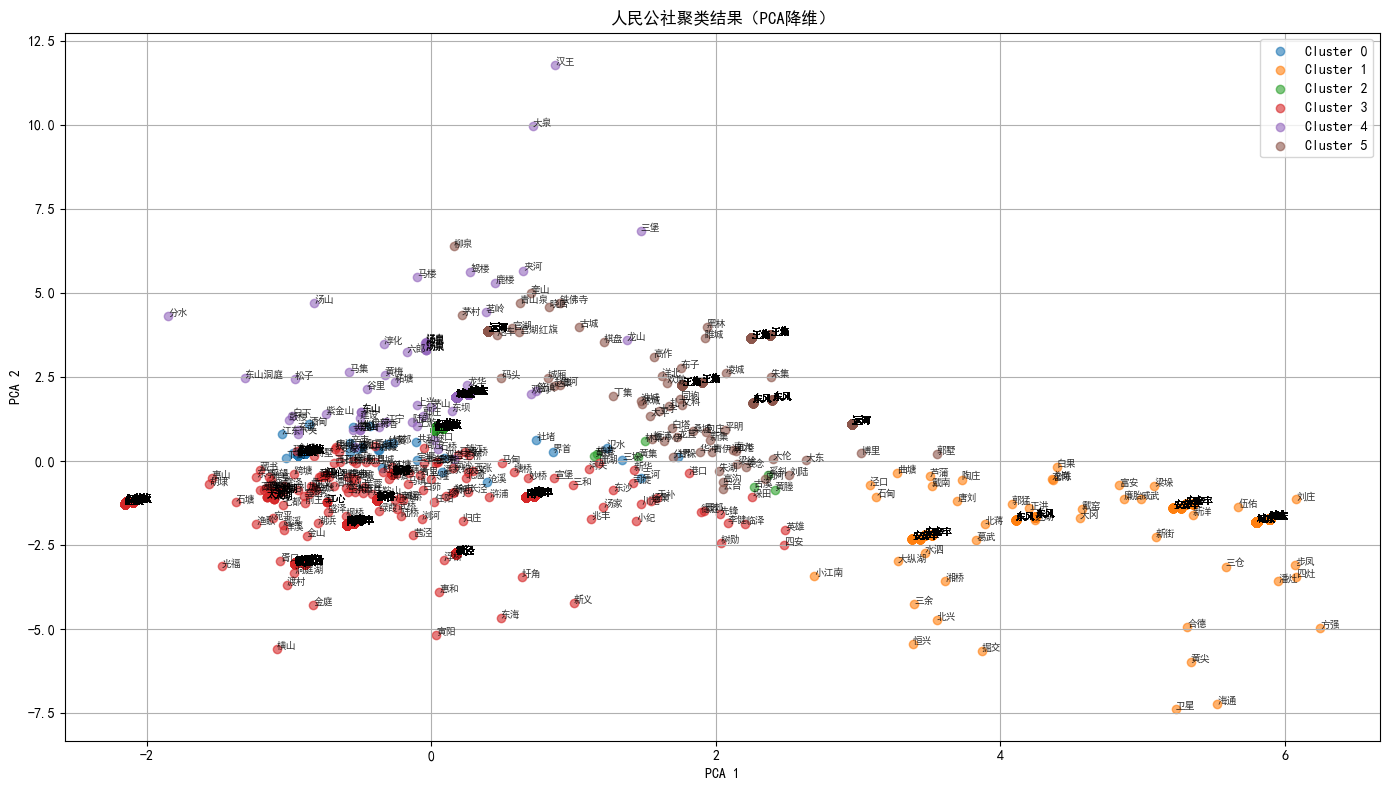

In [18]:
import matplotlib.pyplot as plt

# 设置中文字体（防止乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']   # 适用于 Windows 的中文字体
plt.rcParams['axes.unicode_minus'] = False     # 防止负号显示为方块

# 创建图形
plt.figure(figsize=(14, 8))
for i in range(n_clusters):
    cluster_points = df_clean[df_clean['cluster'] == i]
    plt.scatter(cluster_points['pca1'], cluster_points['pca2'], label=f'Cluster {i}', alpha=0.6)

    # 添加公社名称标签
    for _, row in cluster_points.iterrows():
        plt.text(row['pca1'], row['pca2'], row['name'], fontsize=7, alpha=0.8)

plt.title("人民公社聚类结果（PCA降维）")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()